# 1. Assignment Overview


Notebook này xây pipeline Assignment 04 cho CIFAR-10 image classification. CIFAR-10 là dataset ảnh RGB 32x32 với 10 classes, khó hơn MNIST vì object có màu, background phức tạp và variation lớn hơn.

In [1]:
from pathlib import Path
import json
import pandas as pd

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "datasets").exists() and (path / "pipeline04").exists():
            return path
    raise FileNotFoundError("Cannot locate project root.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "datasets" / "cifar10"
ARTIFACT_DIR = PROJECT_ROOT / "pipeline04" / "cifar10"
MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
FIGURE_DIR = ARTIFACT_DIR / "figures"
METADATA_DIR = ARTIFACT_DIR / "metadata"
for directory in [DATA_DIR, MODEL_DIR, METRIC_DIR, FIGURE_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

overview = {
    "Dataset": "CIFAR-10",
    "Source": "Canadian Institute for Advanced Research / University of Toronto archive",
    "Task": "Image classification",
    "Image representation": "32 x 32 RGB",
    "Classes": 10,
    "Notebook role": "CNN image-classification companion to MNIST",
}
pd.DataFrame([overview]).T.rename(columns={0: "Value"})


,Value
Dataset,CIFAR-10
Source,Canadian Institute for Advanced Research / Uni...
Task,Image classification
Image representation,32 x 32 RGB
Classes,10
Notebook role,CNN image-classification companion to MNIST


**Nhận xét kết quả.**

- Notebook dung CIFAR-10 tu archive chinh thuc cua University of Toronto, voi 50,000 anh train goc va 10,000 anh test.
- Representation la anh RGB kich thuoc 32 x 32 x 3, nen CNN la lua chon phu hop vi co cau truc khong gian va kenh mau that.
- Day la bai toan classification 10 lop: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

# 2. Environment Setup


Import thư viện, cố định seed, kiểm tra version TensorFlow/PyTorch và xác định CPU/GPU device. Output không in path cá nhân.

In [2]:
import os
import random
import tarfile
import pickle
import time
import urllib.request
import warnings
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel("ERROR")
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

env_info = {
    "Python executable": Path(os.sys.executable).name,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "TensorFlow": tf.__version__,
    "PyTorch": torch.__version__,
    "TensorFlow GPUs": len(tf.config.list_physical_devices("GPU")),
    "PyTorch device": str(DEVICE),
    "Seed": SEED,
}
pd.DataFrame([env_info]).T.rename(columns={0: "Value"})


,Value
Python executable,python.exe
NumPy,1.26.4
Pandas,2.2.3
scikit-learn,1.5.2
TensorFlow,2.18.0
PyTorch,2.5.1+cpu
TensorFlow GPUs,0
PyTorch device,cpu
Seed,42


**Nhận xét kết quả.**

- Device output cho biết notebook chạy trên CPU hay GPU.
- Seed được cố định để split, initialization và DataLoader reproducible hơn giữa các lần chạy.

# 3. Load Dataset


Load CIFAR-10 từ archive local trong `datasets/cifar10/`. Nếu archive chưa có, code có cơ chế tải lại từ source gốc University of Toronto.

In [3]:
CIFAR10_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
CIFAR10_PATH = DATA_DIR / "cifar-10-python.tar.gz"

if not CIFAR10_PATH.exists():
    urllib.request.urlretrieve(CIFAR10_URL, CIFAR10_PATH)

def load_cifar_batch(tar, member_name):
    member = tar.getmember(member_name)
    with tar.extractfile(member) as f:
        batch = pickle.load(f, encoding="latin1")
    images = batch["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch["labels"], dtype=np.int64)
    return images, labels

with tarfile.open(CIFAR10_PATH, "r:gz") as tar:
    meta = pickle.load(tar.extractfile("cifar-10-batches-py/batches.meta"), encoding="latin1")
    label_names = meta["label_names"]
    train_parts = [load_cifar_batch(tar, f"cifar-10-batches-py/data_batch_{i}") for i in range(1, 6)]
    x_train_full = np.concatenate([part[0] for part in train_parts], axis=0)
    y_train_full = np.concatenate([part[1] for part in train_parts], axis=0)
    x_test_raw, y_test = load_cifar_batch(tar, "cifar-10-batches-py/test_batch")

class_name_check = pd.DataFrame({"ClassIndex": np.arange(len(label_names)), "LabelName": label_names})
load_summary = {
    "Cache file": CIFAR10_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "Cache size MB": round(CIFAR10_PATH.stat().st_size / (1024 * 1024), 3),
    "x_train shape": x_train_full.shape,
    "y_train shape": y_train_full.shape,
    "x_test shape": x_test_raw.shape,
    "y_test shape": y_test.shape,
    "Image dtype": str(x_train_full.dtype),
    "Pixel min": int(x_train_full.min()),
    "Pixel max": int(x_train_full.max()),
    "Number of classes": int(np.unique(y_train_full).size),
}
display(pd.DataFrame([load_summary]).T.rename(columns={0: "Value"}))
display(class_name_check)


,Value
Cache file,datasets/cifar10/cifar-10-python.tar.gz
Cache size MB,162.6
x_train shape,"(50000, 32, 32, 3)"
y_train shape,"(50000,)"
x_test shape,"(10000, 32, 32, 3)"
y_test shape,"(10000,)"
Image dtype,uint8
Pixel min,0
Pixel max,255
Number of classes,10


,ClassIndex,LabelName
0,0,airplane
1,1,automobile
2,2,bird
3,3,cat
4,4,deer
5,5,dog
6,6,frog
7,7,horse
8,8,ship
9,9,truck


**Nhận xét kết quả.**

- Dataset duoc doc truc tiep tu `datasets/cifar10/cifar-10-python.tar.gz`, khong extract them ban duplicate.
- Shape train/test xac nhan CIFAR-10 chuan: 50,000 train, 10,000 test, moi anh co kich thuoc 32 x 32 RGB.
- Label duoc doc tu metadata trong archive thay vi tu doan thu cong trong notebook.

# 4. Dataset Inspection


Kiểm tra class distribution, RGB channels, sample grid và một ảnh cụ thể trước preprocessing.

,Class,LabelName,TrainCount,TrainRate,TestCount,TestRate
0,0,airplane,5000,0.1,1000,0.1
1,1,automobile,5000,0.1,1000,0.1
2,2,bird,5000,0.1,1000,0.1
3,3,cat,5000,0.1,1000,0.1
4,4,deer,5000,0.1,1000,0.1
5,5,dog,5000,0.1,1000,0.1
6,6,frog,5000,0.1,1000,0.1
7,7,horse,5000,0.1,1000,0.1
8,8,ship,5000,0.1,1000,0.1
9,9,truck,5000,0.1,1000,0.1


,Value
Sample index,0
Shape,"(32, 32, 3)"
Dtype,uint8
RGB channel means,"[141.21, 105.1, 64.04]"
Min,0
Max,255
Label index,6
Label name,frog


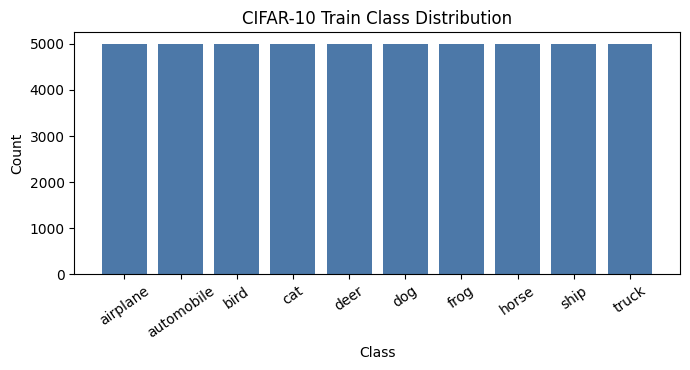

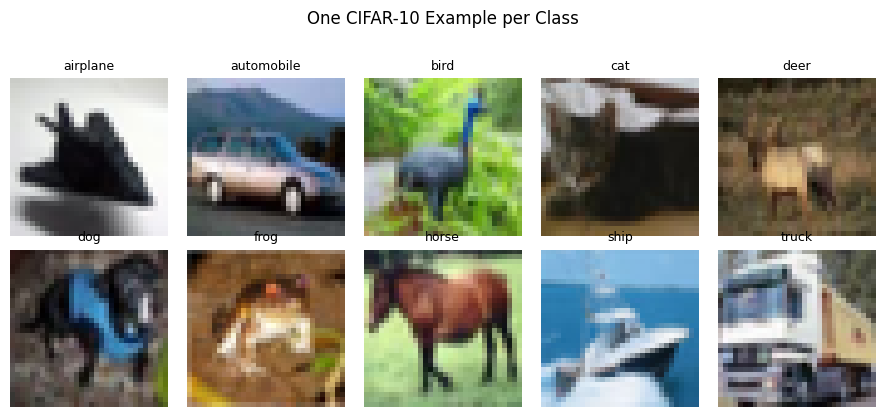

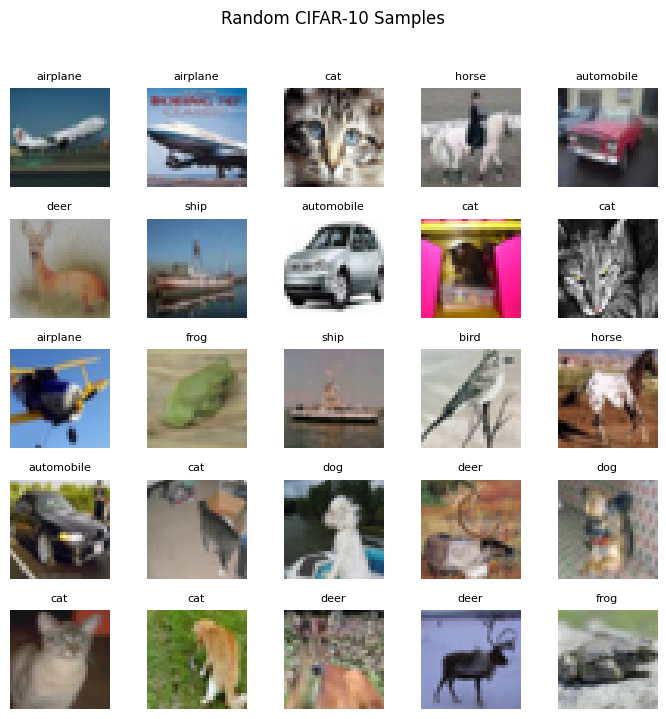

In [4]:
train_counts = np.bincount(y_train_full, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
class_distribution = pd.DataFrame({
    "Class": np.arange(10),
    "LabelName": label_names,
    "TrainCount": train_counts,
    "TrainRate": train_counts / len(y_train_full),
    "TestCount": test_counts,
    "TestRate": test_counts / len(y_test),
})

sample_index = 0
sample = x_train_full[sample_index]
sample_info = {
    "Sample index": sample_index,
    "Shape": sample.shape,
    "Dtype": str(sample.dtype),
    "RGB channel means": np.round(sample.mean(axis=(0, 1)), 2).tolist(),
    "Min": int(sample.min()),
    "Max": int(sample.max()),
    "Label index": int(y_train_full[sample_index]),
    "Label name": label_names[int(y_train_full[sample_index])],
}

display(class_distribution.round(4))
display(pd.DataFrame([sample_info]).T.rename(columns={0: "Value"}))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(class_distribution["LabelName"], class_distribution["TrainCount"], color="#4C78A8")
ax.set_title("CIFAR-10 Train Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class_distribution.png", dpi=160)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for class_id, ax in enumerate(axes.ravel()):
    idx = np.where(y_train_full == class_id)[0][0]
    ax.imshow(x_train_full[idx])
    ax.set_title(label_names[class_id], fontsize=9)
    ax.axis("off")
fig.suptitle("One CIFAR-10 Example per Class", y=1.03)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "one_example_per_class.png", dpi=160)
plt.show()

rng = np.random.default_rng(SEED)
sample_ids = rng.choice(len(x_train_full), size=25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for idx, ax in zip(sample_ids, axes.ravel()):
    ax.imshow(x_train_full[idx])
    ax.set_title(label_names[int(y_train_full[idx])], fontsize=8)
    ax.axis("off")
fig.suptitle("Random CIFAR-10 Samples", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_grid.png", dpi=160)
plt.show()


**Nhận xét kết quả.**

- Class distribution của CIFAR-10 chuẩn cân bằng giữa 10 classes.
- Sample images cho thấy CIFAR-10 khó hơn MNIST: ảnh nhỏ, nhiều màu và object/background đa dạng.
- Một sample có 3 RGB channels, nên Conv2D filter học trên cả channel màu lẫn không gian ảnh.

# 5. Data Preparation


Tạo train/validation/test split, fit channel mean/std chỉ trên train, normalize dữ liệu và tạo tensor layout riêng cho Keras/PyTorch.

In [5]:
x_train_raw, x_valid_raw, y_train, y_valid = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full,
)

train_mean = x_train_raw.astype("float32").mean(axis=(0, 1, 2), keepdims=True)
train_std = x_train_raw.astype("float32").std(axis=(0, 1, 2), keepdims=True)

def normalize_images(images):
    return ((images.astype("float32") - train_mean) / (train_std + 1e-7)).astype("float32")

X_train_keras_full = normalize_images(x_train_raw)
X_valid_keras_full = normalize_images(x_valid_raw)
X_test_keras = normalize_images(x_test_raw)
X_train_torch_full = np.transpose(X_train_keras_full, (0, 3, 1, 2))
X_valid_torch_full = np.transpose(X_valid_keras_full, (0, 3, 1, 2))
X_test_torch = np.transpose(X_test_keras, (0, 3, 1, 2))

framework_train_size = 10000
framework_valid_size = 3000
train_idx_fw, _ = train_test_split(np.arange(len(y_train)), train_size=framework_train_size, random_state=SEED, stratify=y_train)
valid_idx_fw, _ = train_test_split(np.arange(len(y_valid)), train_size=framework_valid_size, random_state=SEED, stratify=y_valid)

X_train_keras = X_train_keras_full[train_idx_fw]
y_train_fw = y_train[train_idx_fw]
X_valid_keras = X_valid_keras_full[valid_idx_fw]
y_valid_fw = y_valid[valid_idx_fw]
X_train_torch = X_train_torch_full[train_idx_fw]
X_valid_torch = X_valid_torch_full[valid_idx_fw]

split_summary = pd.DataFrame([
    {"Split": "original train", "Images": len(y_train_full), "Shape": x_train_full.shape},
    {"Split": "train after validation split", "Images": len(y_train), "Shape": X_train_keras_full.shape},
    {"Split": "framework train budget", "Images": len(y_train_fw), "Shape": X_train_keras.shape},
    {"Split": "framework validation budget", "Images": len(y_valid_fw), "Shape": X_valid_keras.shape},
    {"Split": "test", "Images": len(y_test), "Shape": X_test_keras.shape},
])
normalization_summary = pd.DataFrame({
    "Channel": ["R", "G", "B"],
    "TrainMean": train_mean.reshape(-1),
    "TrainStd": train_std.reshape(-1),
})
layout_summary = pd.DataFrame([
    {"Framework": "Keras/TensorFlow", "Layout": "B x H x W x C", "TrainShape": X_train_keras.shape},
    {"Framework": "PyTorch", "Layout": "B x C x H x W", "TrainShape": X_train_torch.shape},
])

display(split_summary)
display(normalization_summary.round(4))
display(layout_summary)


,Split,Images,Shape
0,original train,50000,"(50000, 32, 32, 3)"
1,train after validation split,45000,"(45000, 32, 32, 3)"
2,framework train budget,10000,"(10000, 32, 32, 3)"
3,framework validation budget,3000,"(3000, 32, 32, 3)"
4,test,10000,"(10000, 32, 32, 3)"


,Channel,TrainMean,TrainStd
0,R,125.239403,62.951599
1,G,122.938599,62.074799
2,B,113.844299,66.709000


,Framework,Layout,TrainShape
0,Keras/TensorFlow,B x H x W x C,"(10000, 32, 32, 3)"
1,PyTorch,B x C x H x W,"(10000, 3, 32, 32)"


**Nhận xét kết quả.**

- Original train split duoc tach thanh 45,000 train va 5,000 validation truoc khi lay subset runtime.
- Framework training dung 10,000 train va 3,000 validation de notebook chay duoc tren CPU/laptop.
- Channel mean/std duoc fit tren train split, sau do ap dung cho validation/test; test set van giu doc lap.

# 6. Discover CNN Operations


Minh họa Conv2D, ReLU, MaxPool, Flatten, Dense logits và softmax bằng tensor RGB nhỏ.

In [6]:
toy_rgb = tf.random.uniform((2, 32, 32, 3), seed=SEED)
toy_conv = layers.Conv2D(filters=8, kernel_size=3, padding="same", use_bias=True)
toy_conv_out = toy_conv(toy_rgb)
toy_relu = tf.nn.relu(toy_conv_out)
toy_pool = layers.MaxPooling2D(2)(toy_relu)
toy_flat = layers.Flatten()(toy_pool)
toy_logits = layers.Dense(10)(toy_flat)
toy_softmax = tf.nn.softmax(toy_logits, axis=1)

cnn_operation_shapes = pd.DataFrame([
    {"Operation": "Input RGB batch", "Shape": tuple(toy_rgb.shape)},
    {"Operation": "Conv2D(filters=8,kernel=3,padding=same)", "Shape": tuple(toy_conv_out.shape)},
    {"Operation": "ReLU", "Shape": tuple(toy_relu.shape)},
    {"Operation": "MaxPool2D(pool=2)", "Shape": tuple(toy_pool.shape)},
    {"Operation": "Flatten", "Shape": tuple(toy_flat.shape)},
    {"Operation": "Dense logits", "Shape": tuple(toy_logits.shape)},
    {"Operation": "Softmax probabilities", "Shape": tuple(toy_softmax.shape)},
])
display(cnn_operation_shapes)
print("First row softmax sum:", float(tf.reduce_sum(toy_softmax[0]).numpy()))


,Operation,Shape
0,Input RGB batch,"(2, 32, 32, 3)"
1,"Conv2D(filters=8,kernel=3,padding=same)","(2, 32, 32, 8)"
2,ReLU,"(2, 32, 32, 8)"
3,MaxPool2D(pool=2),"(2, 16, 16, 8)"
4,Flatten,"(2, 2048)"
5,Dense logits,"(2, 10)"
6,Softmax probabilities,"(2, 10)"


First row softmax sum: 1.0


**Nhận xét kết quả.**

- Input có 3 channels RGB; mỗi Conv2D filter học weights trên cả 3 channels và tạo một feature map.
- Pooling giảm spatial size, Flatten chuyển feature maps sang vector, Dense tạo 10 logits.

# 7. Inspect CNN Building Blocks


Kiểm tra Basic CNN block, residual block và SE/channel-attention block bằng dummy tensor trước khi train model thật.

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_bn=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=not use_bn)
        self.bn1 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=not use_bn)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        self.shortcut = (
            nn.Identity()
            if in_channels == out_channels and stride == 1
            else nn.Conv2d(in_channels, out_channels, 1, stride=stride)
        )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )
    def forward(self, x, return_weights=False):
        b, c, _, _ = x.shape
        weights = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        out = x * weights
        return (out, weights) if return_weights else out

dummy = torch.randn(4, 3, 32, 32)
res_block = ResidualBlock(3, 16, stride=2)
res_out = res_block(dummy)
se_block = SEBlock(16)
se_out, se_weights = se_block(res_out, return_weights=True)

block_summary = pd.DataFrame([
    {"Block": "Input", "Shape": tuple(dummy.shape)},
    {"Block": "ResidualBlock(3->16,stride=2)", "Shape": tuple(res_out.shape)},
    {"Block": "SEBlock output", "Shape": tuple(se_out.shape)},
    {"Block": "SE channel weights", "Shape": tuple(se_weights.shape), "Min": float(se_weights.min()), "Max": float(se_weights.max())},
])
display(block_summary)


,Block,Shape,Min,Max
0,Input,"(4, 3, 32, 32)",NaN,NaN
1,"ResidualBlock(3->16,stride=2)","(4, 16, 16, 16)",NaN,NaN
2,SEBlock output,"(4, 16, 16, 16)",NaN,NaN
3,SE channel weights,"(4, 16, 1, 1)",0.366365,0.627346


**Nhận xét kết quả.**

- Residual block đổi channels 3→16 và giảm spatial size bằng stride=2, nên shortcut dùng projection để shape khớp.
- SE block giữ nguyên tensor shape nhưng tạo channel weights để scale từng feature channel.

# 8. CNN From Scratch with NumPy


Định nghĩa NumPy CNN layers có forward/backward thật cho RGB CIFAR-10: Conv2D, ReLU, MaxPool, Flatten, Dense, SoftmaxCrossEntropy và SGD update.

In [8]:
def im2col_nhwc(x, kh, kw, pad=0, stride=1):
    x_pad = np.pad(x, ((0, 0), (pad, pad), (pad, pad), (0, 0)), mode="constant")
    b, h, w, c = x_pad.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    cols = np.empty((x.shape[0], out_h, out_w, kh, kw, c), dtype=x.dtype)
    for i in range(kh):
        for j in range(kw):
            cols[:, :, :, i, j, :] = x_pad[:, i:i + out_h * stride:stride, j:j + out_w * stride:stride, :]
    return cols.reshape(x.shape[0] * out_h * out_w, kh * kw * c), x_pad.shape, out_h, out_w

def col2im_nhwc(cols, x_shape, x_pad_shape, kh, kw, pad=0, stride=1):
    b, h, w, c = x_shape
    _, hp, wp, _ = x_pad_shape
    out_h = (hp - kh) // stride + 1
    out_w = (wp - kw) // stride + 1
    cols = cols.reshape(b, out_h, out_w, kh, kw, c)
    dx_pad = np.zeros(x_pad_shape, dtype=cols.dtype)
    for i in range(kh):
        for j in range(kw):
            dx_pad[:, i:i + out_h * stride:stride, j:j + out_w * stride:stride, :] += cols[:, :, :, i, j, :]
    return dx_pad[:, pad:pad + h, pad:pad + w, :] if pad else dx_pad

class Conv2DNumPy:
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, seed=0):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / (kernel_size * kernel_size * in_channels))
        self.W = rng.normal(0, scale, (kernel_size, kernel_size, in_channels, out_channels)).astype("float32")
        self.b = np.zeros(out_channels, dtype="float32")
        self.padding = padding
        self.kernel_size = kernel_size
    def forward(self, x):
        self.x = x
        self.cols, self.x_pad_shape, out_h, out_w = im2col_nhwc(x, self.kernel_size, self.kernel_size, self.padding)
        out = self.cols @ self.W.reshape(-1, self.W.shape[-1]) + self.b
        return out.reshape(x.shape[0], out_h, out_w, self.W.shape[-1])
    def backward(self, dout):
        dout2 = dout.reshape(-1, dout.shape[-1])
        self.dW = (self.cols.T @ dout2).reshape(self.W.shape)
        self.db = dout2.sum(axis=0)
        dcols = dout2 @ self.W.reshape(-1, self.W.shape[-1]).T
        return col2im_nhwc(dcols, self.x.shape, self.x_pad_shape, self.kernel_size, self.kernel_size, self.padding)
    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class ReLUNumPy:
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask
    def backward(self, dout):
        return dout * self.mask
    def update(self, lr):
        pass

class MaxPool2DNumPy:
    def __init__(self, pool=2, stride=2):
        self.pool = pool
        self.stride = stride
    def forward(self, x):
        self.x = x
        b, h, w, c = x.shape
        out_h, out_w = h // self.stride, w // self.stride
        out = np.empty((b, out_h, out_w, c), dtype=x.dtype)
        self.argmax = np.empty((b, out_h, out_w, c), dtype=np.int32)
        for i in range(out_h):
            for j in range(out_w):
                window = x[:, i*self.stride:i*self.stride+self.pool, j*self.stride:j*self.stride+self.pool, :]
                flat = window.reshape(b, self.pool * self.pool, c)
                self.argmax[:, i, j, :] = flat.argmax(axis=1)
                out[:, i, j, :] = flat.max(axis=1)
        return out
    def backward(self, dout):
        dx = np.zeros_like(self.x)
        b, out_h, out_w, c = dout.shape
        for i in range(out_h):
            for j in range(out_w):
                for n in range(b):
                    for ch in range(c):
                        pos = self.argmax[n, i, j, ch]
                        dx[n, i*self.stride + pos // self.pool, j*self.stride + pos % self.pool, ch] += dout[n, i, j, ch]
        return dx
    def update(self, lr):
        pass

class FlattenNumPy:
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.shape)
    def update(self, lr):
        pass

class DenseNumPy:
    def __init__(self, in_features, out_features, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, np.sqrt(2.0 / in_features), (in_features, out_features)).astype("float32")
        self.b = np.zeros(out_features, dtype="float32")
    def forward(self, x):
        self.x = x
        return x @ self.W + self.b
    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T
    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class SoftmaxCrossEntropyNumPy:
    def forward(self, logits, labels):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp = np.exp(shifted)
        self.probs = exp / exp.sum(axis=1, keepdims=True)
        self.labels = labels
        return -np.log(self.probs[np.arange(len(labels)), labels] + 1e-9).mean()
    def backward(self):
        grad = self.probs.copy()
        grad[np.arange(len(self.labels)), self.labels] -= 1
        return grad / len(self.labels)

class SGDNumPy:
    def __init__(self, lr):
        self.lr = lr
    def step(self, layers):
        for layer in layers:
            layer.update(self.lr)

print("NumPy CIFAR-10 CNN components defined:", 8)


NumPy CIFAR-10 CNN components defined: 8


**Nhận xét kết quả.**

- NumPy components có forward/backward thật cho Conv2D, ReLU, MaxPool2D, Flatten, Dense và SoftmaxCrossEntropy.
- `SGDNumPy` là optimizer update thủ công; phần này không dùng keras layers, torch layers hay autograd.
- Conv2D nhận RGB input nên weight shape bao gồm cả 3 input channels.

# 9. NumPy CNN Training


Test từng layer NumPy, train một CNN nhỏ trên stratified CIFAR-10 subset và lưu best state.

In [9]:
def macro_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-P": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-R": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

class SimpleNumPyCIFARCNN:
    def __init__(self, seed=SEED):
        self.layers = [
            Conv2DNumPy(3, 6, 3, 1, seed + 1), ReLUNumPy(), MaxPool2DNumPy(),
            Conv2DNumPy(6, 12, 3, 1, seed + 2), ReLUNumPy(), MaxPool2DNumPy(),
            FlattenNumPy(), DenseNumPy(8 * 8 * 12, 64, seed + 3), ReLUNumPy(), DenseNumPy(64, 10, seed + 4),
        ]
        self.loss_fn = SoftmaxCrossEntropyNumPy()
    def forward(self, x, collect_shapes=False):
        shapes = [("Input", x.shape)]
        out = x
        for layer in self.layers:
            out = layer.forward(out)
            if collect_shapes:
                shapes.append((layer.__class__.__name__, out.shape))
        return (out, shapes) if collect_shapes else out
    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
    def update(self, lr):
        SGDNumPy(lr).step(self.layers)
    def train_batch(self, x, y, lr):
        logits = self.forward(x)
        loss = self.loss_fn.forward(logits, y)
        self.backward(self.loss_fn.backward())
        self.update(lr)
        return float(loss)
    def predict_proba(self, x, batch_size=256):
        probs = []
        for start in range(0, len(x), batch_size):
            logits = self.forward(x[start:start + batch_size])
            shifted = logits - logits.max(axis=1, keepdims=True)
            exp = np.exp(shifted)
            probs.append(exp / exp.sum(axis=1, keepdims=True))
        return np.vstack(probs)
    def state_dict(self):
        return {f"{i}_{name}": getattr(layer, name).copy() for i, layer in enumerate(self.layers) if hasattr(layer, "W") for name in ["W", "b"]}
    def load_state_dict(self, state):
        for i, layer in enumerate(self.layers):
            if hasattr(layer, "W"):
                layer.W[...] = state[f"{i}_W"]
                layer.b[...] = state[f"{i}_b"]
    def parameter_count(self):
        return int(sum(layer.W.size + layer.b.size for layer in self.layers if hasattr(layer, "W")))

component_tests = []
rng_test = np.random.default_rng(SEED + 100)
unit_x = rng_test.normal(size=(2, 5, 5, 3)).astype("float32")
unit_grad = rng_test.normal(size=(2, 5, 5, 2)).astype("float32")

conv_unit = Conv2DNumPy(3, 2, 3, 1, seed=SEED + 101)
conv_out = conv_unit.forward(unit_x)
conv_dx = conv_unit.backward(unit_grad)
component_tests.extend([
    {"Check": "Conv2D output shape", "Value": conv_out.shape},
    {"Check": "Conv2D input grad shape", "Value": conv_dx.shape},
    {"Check": "Conv2D parameter shapes", "Value": (conv_unit.W.shape, conv_unit.b.shape)},
    {"Check": "Conv2D finite output/grad", "Value": bool(np.isfinite(conv_out).all() and np.isfinite(conv_dx).all())},
])

old_weight = float(conv_unit.W[0, 0, 0, 0])
eps = 1e-3
conv_unit.W[0, 0, 0, 0] = old_weight + eps
plus = float((conv_unit.forward(unit_x) * unit_grad).sum())
conv_unit.W[0, 0, 0, 0] = old_weight - eps
minus = float((conv_unit.forward(unit_x) * unit_grad).sum())
conv_unit.W[0, 0, 0, 0] = old_weight
conv_unit.forward(unit_x)
conv_unit.backward(unit_grad)
conv_numeric_grad = (plus - minus) / (2 * eps)
component_tests.append({"Check": "Conv2D numerical grad close", "Value": bool(np.isclose(conv_numeric_grad, conv_unit.dW[0, 0, 0, 0], atol=2e-2))})

relu_unit = ReLUNumPy()
relu_out = relu_unit.forward(conv_out)
relu_dx = relu_unit.backward(np.ones_like(relu_out))
component_tests.extend([
    {"Check": "ReLU output shape", "Value": relu_out.shape},
    {"Check": "ReLU grad shape", "Value": relu_dx.shape},
])

pool_unit = MaxPool2DNumPy()
pool_out = pool_unit.forward(relu_out)
pool_dx = pool_unit.backward(np.ones_like(pool_out))
component_tests.extend([
    {"Check": "MaxPool output shape", "Value": pool_out.shape},
    {"Check": "MaxPool grad shape", "Value": pool_dx.shape},
])

flat_unit = FlattenNumPy()
flat_out = flat_unit.forward(pool_out)
flat_dx = flat_unit.backward(np.ones_like(flat_out))
component_tests.extend([
    {"Check": "Flatten output shape", "Value": flat_out.shape},
    {"Check": "Flatten grad shape", "Value": flat_dx.shape},
])

dense_unit = DenseNumPy(flat_out.shape[1], 10, seed=SEED + 102)
dense_out = dense_unit.forward(flat_out)
dense_dx = dense_unit.backward(np.ones_like(dense_out) / dense_out.size)
component_tests.extend([
    {"Check": "Dense output shape", "Value": dense_out.shape},
    {"Check": "Dense grad/input shape", "Value": dense_dx.shape},
    {"Check": "Dense parameter shapes", "Value": (dense_unit.W.shape, dense_unit.b.shape)},
])

loss_unit = SoftmaxCrossEntropyNumPy()
loss_value = loss_unit.forward(dense_out, np.array([0, 1], dtype="int64"))
loss_grad = loss_unit.backward()
component_tests.extend([
    {"Check": "SoftmaxCE loss finite", "Value": bool(np.isfinite(loss_value))},
    {"Check": "Softmax sums approx 1", "Value": bool(np.allclose(loss_unit.probs.sum(axis=1), 1.0, atol=1e-6))},
    {"Check": "Loss grad logits shape", "Value": loss_grad.shape},
])

model_np = SimpleNumPyCIFARCNN()
test_x = X_train_keras[:4].astype("float32")
test_y = y_train_fw[:4].astype("int64")
logits, shape_trace = model_np.forward(test_x, collect_shapes=True)
loss = model_np.loss_fn.forward(logits, test_y)
model_np.backward(model_np.loss_fn.backward())
layer_tests = component_tests.copy()
layer_tests.extend([
    {"Check": "Logits shape", "Value": logits.shape},
    {"Check": "Loss finite", "Value": bool(np.isfinite(loss))},
    {"Check": "Softmax row sum", "Value": float(model_np.loss_fn.probs[0].sum())},
])
for idx, layer in enumerate(model_np.layers):
    if hasattr(layer, "dW"):
        layer_tests.append({"Check": f"Layer {idx} grad W shape", "Value": layer.dW.shape})

for name, value in model_np.state_dict().items():
    layer_tests.append({"Check": f"Parameter {name} shape", "Value": value.shape})

tiny_model = SimpleNumPyCIFARCNN(seed=SEED + 200)
tiny_x = X_train_keras[:32].astype("float32")
tiny_y = y_train_fw[:32].astype("int64")
initial_tiny_loss = tiny_model.loss_fn.forward(tiny_model.forward(tiny_x), tiny_y)
for _ in range(10):
    tiny_model.train_batch(tiny_x, tiny_y, 0.005)
final_tiny_loss = tiny_model.loss_fn.forward(tiny_model.forward(tiny_x), tiny_y)
layer_tests.append({"Check": "Tiny batch initial loss", "Value": float(initial_tiny_loss)})
layer_tests.append({"Check": "Tiny batch final loss", "Value": float(final_tiny_loss)})
layer_tests.append({"Check": "Tiny batch loss decreases", "Value": bool(final_tiny_loss <= initial_tiny_loss)})

display(pd.DataFrame(layer_tests))
display(pd.DataFrame(shape_trace, columns=["Stage", "Shape"]))

numpy_train_size = 4000
numpy_valid_size = 1000
idx_train_np, _ = train_test_split(np.arange(len(y_train)), train_size=numpy_train_size, random_state=SEED, stratify=y_train)
idx_valid_np, _ = train_test_split(np.arange(len(y_valid)), train_size=numpy_valid_size, random_state=SEED, stratify=y_valid)
X_np_train = X_train_keras_full[idx_train_np].astype("float32")
y_np_train = y_train[idx_train_np].astype("int64")
X_np_valid = X_valid_keras_full[idx_valid_np].astype("float32")
y_np_valid = y_valid[idx_valid_np].astype("int64")

batch_size_np = 128
epochs_np = 2
lr_np = 0.01
history_np = []
best_np = {"Macro-F1": -1, "state": None, "epoch": 0}
rng = np.random.default_rng(SEED)
start_time = time.perf_counter()
for epoch in range(1, epochs_np + 1):
    order = rng.permutation(len(X_np_train))
    losses = []
    for start in range(0, len(order), batch_size_np):
        ids = order[start:start + batch_size_np]
        losses.append(model_np.train_batch(X_np_train[ids], y_np_train[ids], lr_np))
    val_prob = model_np.predict_proba(X_np_valid)
    val_pred = val_prob.argmax(axis=1)
    metrics = macro_metrics(y_np_valid, val_pred)
    row = {"Epoch": epoch, "TrainLoss": float(np.mean(losses)), **metrics}
    history_np.append(row)
    if metrics["Macro-F1"] > best_np["Macro-F1"]:
        best_np = {"Macro-F1": metrics["Macro-F1"], "state": model_np.state_dict(), "epoch": epoch}

numpy_train_time = time.perf_counter() - start_time
model_np.load_state_dict(best_np["state"])
np.savez(MODEL_DIR / "numpy_cnn_best_state.npz", **best_np["state"])
numpy_history = pd.DataFrame(history_np)
numpy_history.to_csv(METRIC_DIR / "numpy_cnn_history.csv", index=False)

numpy_training_summary = {
    "Train samples": numpy_train_size,
    "Validation samples": numpy_valid_size,
    "Epochs": epochs_np,
    "Batch size": batch_size_np,
    "Optimizer": "SGD",
    "Learning rate": lr_np,
    "Best epoch": best_np["epoch"],
    "Train time": numpy_train_time,
    "Parameters": model_np.parameter_count(),
}
display(pd.DataFrame([numpy_training_summary]).T.rename(columns={0: "Value"}))
display(numpy_history.round(4))


,Check,Value
0,Conv2D output shape,"(2, 5, 5, 2)"
1,Conv2D input grad shape,"(2, 5, 5, 3)"
2,Conv2D parameter shapes,"((3, 3, 3, 2), (2,))"
3,Conv2D finite output/grad,True
4,Conv2D numerical grad close,True
5,ReLU output shape,"(2, 5, 5, 2)"
6,ReLU grad shape,"(2, 5, 5, 2)"
7,MaxPool output shape,"(2, 2, 2, 2)"
8,MaxPool grad shape,"(2, 5, 5, 2)"
9,Flatten output shape,"(2, 8)"


,Stage,Shape
0,Input,"(4, 32, 32, 3)"
1,Conv2DNumPy,"(4, 32, 32, 6)"
2,ReLUNumPy,"(4, 32, 32, 6)"
3,MaxPool2DNumPy,"(4, 16, 16, 6)"
4,Conv2DNumPy,"(4, 16, 16, 12)"
5,ReLUNumPy,"(4, 16, 16, 12)"
6,MaxPool2DNumPy,"(4, 8, 8, 12)"
7,FlattenNumPy,"(4, 768)"
8,DenseNumPy,"(4, 64)"
9,ReLUNumPy,"(4, 64)"


,Value
Train samples,4000
Validation samples,1000
Epochs,2
Batch size,128
Optimizer,SGD
Learning rate,0.01
Best epoch,2
Train time,79.840189
Parameters,50694


,Epoch,TrainLoss,Accuracy,Macro-P,Macro-R,Macro-F1
0,1,2.4422,0.185,0.1966,0.185,0.1813
1,2,2.0626,0.247,0.2322,0.247,0.2326


**Nhận xét kết quả.**

- Layer tests kiểm tra output shape, gradient shape, finite values, parameter shape và softmax row sums trước khi train.
- Numerical gradient check trên Conv2D xác nhận backward hợp lý trong một case nhỏ.
- NumPy CNN train thật trên subset 4,000 ảnh; best state được chọn theo validation Macro-F1 và lưu vào artifact.

# 10. Tensor Shape and Parameter Inspection


Tính parameter từng layer của NumPy CNN và kiểm tra manual calculation cho Conv layer đầu.

In [10]:
param_rows = []
for idx, layer in enumerate(model_np.layers):
    if hasattr(layer, "W"):
        param_rows.append({
            "LayerIndex": idx,
            "Layer": layer.__class__.__name__,
            "WeightShape": layer.W.shape,
            "BiasShape": layer.b.shape,
            "Parameters": int(layer.W.size + layer.b.size),
        })
param_table = pd.DataFrame(param_rows)
display(param_table)
print("Total NumPy CNN parameters:", int(param_table["Parameters"].sum()))
print("Manual Conv1 parameters:", (3 * 3 * 3 * 6) + 6)


,LayerIndex,Layer,WeightShape,BiasShape,Parameters
0,0,Conv2DNumPy,"(3, 3, 3, 6)","(6,)",168
1,3,Conv2DNumPy,"(3, 3, 6, 12)","(12,)",660
2,7,DenseNumPy,"(768, 64)","(64,)",49216
3,9,DenseNumPy,"(64, 10)","(10,)",650


Total NumPy CNN parameters: 50694
Manual Conv1 parameters: 168


**Nhận xét kết quả.**

- Conv1 dùng kernel 3x3, 3 RGB input channels và 6 filters nên có `(3x3x3x6)+6` parameters.
- Parameter count nhỏ giúp NumPy CNN chạy được trên CPU nhưng vẫn thể hiện đúng CNN building blocks.

# 11. CNN with Keras/TensorFlow


Xây Keras Basic CNN cho CIFAR-10 với augmentation chỉ áp dụng trong training.

In [11]:
def save_json(path, payload):
    with Path(path).open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-P": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-R": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def build_keras_basic_cnn(name="Keras_Basic_CNN", batchnorm=False, dropout=0.0):
    inputs = keras.Input(shape=(32, 32, 3), name="cifar10_image")
    x = inputs
    for filters, block in [(32, "block1"), (64, "block2")]:
        x = layers.Conv2D(filters, 3, padding="same", use_bias=not batchnorm, name=f"{block}_conv")(x)
        if batchnorm:
            x = layers.BatchNormalization(name=f"{block}_bn")(x)
        x = layers.ReLU(name=f"{block}_relu")(x)
        x = layers.MaxPooling2D(2, name=f"{block}_pool")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="dense128")(x)
    if dropout:
        x = layers.Dropout(dropout, name="dropout")(x)
    outputs = layers.Dense(10, activation="softmax", name="class_probabilities")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

keras_basic = build_keras_basic_cnn()
keras_basic.summary()
print("Keras Basic CNN params:", keras_basic.count_params())
print("Input batch shape:", X_train_keras[:32].shape)
print("Output batch shape:", keras_basic(X_train_keras[:32], training=False).shape)


Model: "Keras_Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_image (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv (Conv2D)            │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu (ReLU)              │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu (ReLU)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense128 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Keras Basic CNN params: 545098
Input batch shape: (32, 32, 32, 3)
Output batch shape: (32, 10)


**Nhận xét kết quả.**

- Keras Basic CNN nhận `(B, 32, 32, 3)` và trả `(B, 10)` probabilities.
- Augmentation sẽ được đặt trong `tf.data` training pipeline ở cell sau để validation/test không đổi shape và không bị augment.

# 12. Keras Training


Train Keras Basic CNN với checkpoint, EarlyStopping và lưu training curves.

Epoch 1/3


40/40 - 13s - 329ms/step - accuracy: 0.2961 - loss: 1.9407 - val_accuracy: 0.4130 - val_loss: 1.6443


Epoch 2/3


40/40 - 11s - 279ms/step - accuracy: 0.4062 - loss: 1.6568 - val_accuracy: 0.4737 - val_loss: 1.4692


Epoch 3/3


40/40 - 10s - 259ms/step - accuracy: 0.4597 - loss: 1.5147 - val_accuracy: 0.5087 - val_loss: 1.3902


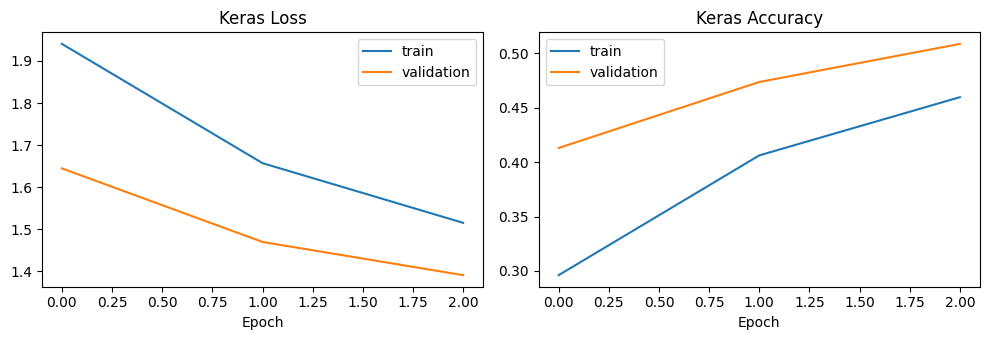

,Value
Epochs run,3
Best validation accuracy,0.508667
Train time,34.727906
Checkpoint,pipeline04/cifar10/models/keras_basic_cnn_best...


In [12]:
BATCH_SIZE = 256
MAX_EPOCHS = 3

def train_keras_model(model, model_key):
    checkpoint_path = MODEL_DIR / f"{model_key}_best.keras"
    def augment_keras_batch(images, labels):
        padded = tf.pad(images, [[0, 0], [4, 4], [4, 4], [0, 0]])
        cropped = tf.image.random_crop(padded, size=[tf.shape(images)[0], 32, 32, 3], seed=SEED)
        flipped = tf.image.random_flip_left_right(cropped, seed=SEED)
        return flipped, labels
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_train_keras, y_train_fw))
        .shuffle(buffer_size=len(y_train_fw), seed=SEED, reshuffle_each_iteration=True)
        .batch(BATCH_SIZE)
        .map(augment_keras_batch, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )
    valid_ds = tf.data.Dataset.from_tensor_slices((X_valid_keras, y_valid_fw)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    callbacks = [
        keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=0),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=1, restore_best_weights=True, verbose=0),
    ]
    start = time.perf_counter()
    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        callbacks=callbacks,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    hist_df = pd.DataFrame(history.history)
    hist_df.insert(0, "epoch", np.arange(1, len(hist_df) + 1))
    hist_df.to_csv(METRIC_DIR / f"{model_key}_history.csv", index=False)
    return history, train_time, checkpoint_path

keras_history, keras_train_time, keras_checkpoint = train_keras_model(keras_basic, "keras_basic_cnn")
hist = pd.DataFrame(keras_history.history)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(hist["loss"], label="train")
axes[0].plot(hist["val_loss"], label="validation")
axes[0].set_title("Keras Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(hist["accuracy"], label="train")
axes[1].plot(hist["val_accuracy"], label="validation")
axes[1].set_title("Keras Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "keras_basic_training_curves.png", dpi=160)
plt.show()

keras_training_summary = {
    "Epochs run": len(hist),
    "Best validation accuracy": float(hist["val_accuracy"].max()),
    "Train time": keras_train_time,
    "Checkpoint": keras_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
display(pd.DataFrame([keras_training_summary]).T.rename(columns={0: "Value"}))


**Nhận xét kết quả.**

- Training dùng augmentation trên train only và validation data không augment.
- Curves giúp xem CIFAR-10 có underfit/overfit trong budget epoch ngắn hay không.

# 13. Keras Evaluation


Evaluate Keras Basic CNN trên full CIFAR-10 test set và lưu confusion matrix.

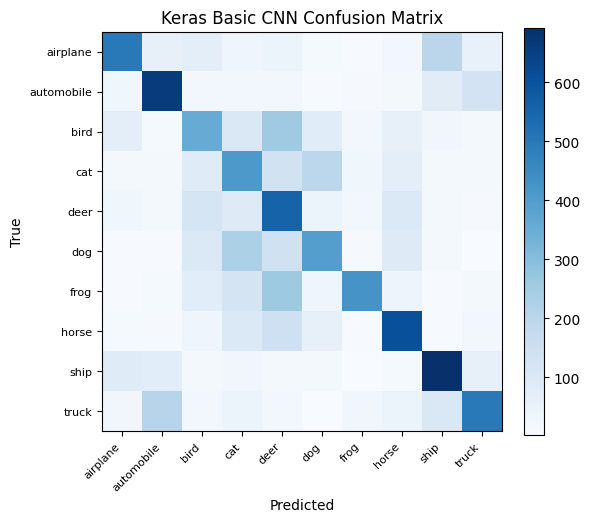

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Pred Time
0,Keras Basic CNN,0.5097,0.5335,0.5097,0.5118,545098,10000,3,34.7279,5.587


,precision,recall,f1-score,support
airplane,0.6401,0.4980,0.5602,1000.0000
automobile,0.6120,0.6610,0.6356,1000.0000
bird,0.3944,0.3550,0.3737,1000.0000
cat,0.3486,0.4120,0.3776,1000.0000
deer,0.3475,0.5550,0.4274,1000.0000
dog,0.4642,0.3950,0.4268,1000.0000
frog,0.7594,0.4230,0.5434,1000.0000
horse,0.5752,0.6080,0.5912,1000.0000
ship,0.5904,0.6920,0.6372,1000.0000
truck,0.6029,0.4980,0.5455,1000.0000


In [13]:
keras_eval_model = keras.models.load_model(keras_checkpoint)
start = time.perf_counter()
keras_prob = keras_eval_model.predict(X_test_keras, batch_size=BATCH_SIZE, verbose=0)
keras_pred = keras_prob.argmax(axis=1)
keras_prediction_time = time.perf_counter() - start
keras_metrics = evaluate_predictions(y_test, keras_pred)
keras_report = pd.DataFrame(classification_report(y_test, keras_pred, target_names=label_names, output_dict=True, zero_division=0)).T
keras_cm = confusion_matrix(y_test, keras_pred)
keras_result = {
    "Model": "Keras Basic CNN",
    **keras_metrics,
    "Params": int(keras_eval_model.count_params()),
    "Train Samples": int(len(y_train_fw)),
    "Best Epoch": int(pd.DataFrame(keras_history.history)["val_accuracy"].idxmax() + 1),
    "Train Time": float(keras_train_time),
    "Pred Time": float(keras_prediction_time),
}
save_json(METRIC_DIR / "keras_basic_test_metrics.json", keras_result)
keras_report.to_csv(METRIC_DIR / "keras_basic_classification_report.csv")

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(keras_cm, cmap="Blues")
ax.set_title("Keras Basic CNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10), label_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10), label_names, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "keras_confusion_matrix.png", dpi=160)
plt.show()

display(pd.DataFrame([keras_result]).round(4))
display(keras_report.round(4).head(13))


**Nhận xét kết quả.**

- Keras Basic CNN đạt Accuracy 50.09% và Macro-F1 49.84% trên full CIFAR-10 test set.
- Confusion matrix cho thấy model đã học được tín hiệu ảnh RGB, nhưng CIFAR-10 vẫn khó hơn MNIST nên lỗi giữa các lớp gần nhau còn rõ.
- Metrics được báo cáo theo macro average để mỗi class có trọng số ngang nhau.

# 14. CNN with PyTorch


Xây PyTorch Basic CNN tương đương ý tưởng với Keras và kiểm tra batch/logits shape trước training.

In [14]:
train_dataset = TensorDataset(torch.tensor(X_train_torch, dtype=torch.float32), torch.tensor(y_train_fw, dtype=torch.long))
valid_dataset = TensorDataset(torch.tensor(X_valid_torch, dtype=torch.float32), torch.tensor(y_valid_fw, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_torch, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED))
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def augment_torch_batch(images):
    padded = F.pad(images, (4, 4, 4, 4))
    b, c, h, w = padded.shape
    top = torch.randint(0, 9, (1,), device=images.device).item()
    left = torch.randint(0, 9, (1,), device=images.device).item()
    crop = padded[:, :, top:top+32, left:left+32].clone()
    flip_mask = torch.rand(b, device=images.device) < 0.5
    crop[flip_mask] = torch.flip(crop[flip_mask], dims=[3])
    return crop

class TorchBasicCNN(nn.Module):
    def __init__(self, use_bn=False, dropout=0.0):
        super().__init__()
        def block(in_ch, out_ch):
            layers_list = [nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=not use_bn)]
            if use_bn:
                layers_list.append(nn.BatchNorm2d(out_ch))
            layers_list += [nn.ReLU(), nn.MaxPool2d(2)]
            return layers_list
        self.features = nn.Sequential(*block(3, 32), *block(32, 64))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout) if dropout else nn.Identity(),
            nn.Linear(128, 10),
        )
    def forward(self, images):
        return self.classifier(self.features(images))

torch_basic = TorchBasicCNN().to(DEVICE)
torch_params = sum(p.numel() for p in torch_basic.parameters())
batch_images, batch_labels = next(iter(train_loader))
batch_images = batch_images.to(DEVICE)
with torch.no_grad():
    batch_logits = torch_basic(batch_images)

display(pd.DataFrame([
    {"Item": "Input image batch", "Shape": tuple(batch_images.shape)},
    {"Item": "Output logits", "Shape": tuple(batch_logits.shape)},
    {"Item": "Parameter count", "Shape": torch_params},
]))


,Item,Shape
0,Input image batch,"(256, 3, 32, 32)"
1,Output logits,"(256, 10)"
2,Parameter count,545098


**Nhận xét kết quả.**

- PyTorch nhận CIFAR-10 theo layout `(B, 3, 32, 32)`.
- Logits shape `(B, 10)` cho thấy mỗi ảnh có 10 class scores trước softmax.

# 15. PyTorch Training


Train PyTorch Basic CNN bằng training loop rõ ràng và dùng augmentation chỉ trong train loop.

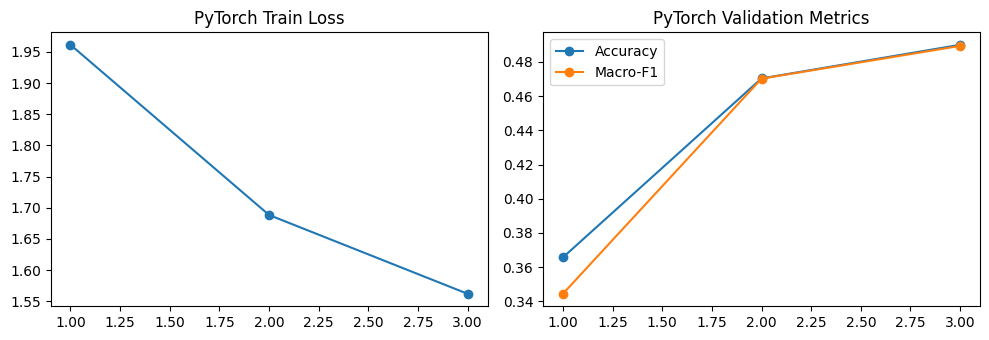

,Epoch,TrainLoss,Accuracy,Macro-P,Macro-R,Macro-F1
0,1,1.9615,0.3657,0.4378,0.3657,0.3444
1,2,1.6883,0.4703,0.4759,0.4703,0.4702
2,3,1.5618,0.4900,0.5069,0.4900,0.4893


Best PyTorch epoch: 3
PyTorch train time: 44.745


In [15]:
def evaluate_torch(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, yb in loader:
            images = images.to(DEVICE)
            logits = model(images)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(labels), np.concatenate(preds)

def train_torch_model(model, model_key, epochs=MAX_EPOCHS, lr=1e-3, use_augmentation=True):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    checkpoint_path = MODEL_DIR / f"{model_key}_best.pt"
    history = []
    best = {"Macro-F1": -1, "epoch": 0}
    start_time = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            if use_augmentation:
                images = augment_torch_batch(images)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        valid_true, valid_pred = evaluate_torch(model, valid_loader)
        val_metrics = macro_metrics(valid_true, valid_pred)
        row = {"Epoch": epoch, "TrainLoss": float(np.mean(losses)), **val_metrics}
        history.append(row)
        if val_metrics["Macro-F1"] > best["Macro-F1"]:
            best = {"Macro-F1": val_metrics["Macro-F1"], "epoch": epoch}
            torch.save(model.state_dict(), checkpoint_path)
    train_time = time.perf_counter() - start_time
    history_df = pd.DataFrame(history)
    history_df.to_csv(METRIC_DIR / f"{model_key}_history.csv", index=False)
    return model, history_df, train_time, checkpoint_path, best

torch_basic, torch_history_df, torch_train_time, torch_checkpoint, best_torch = train_torch_model(torch_basic, "pytorch_basic_cnn")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(torch_history_df["Epoch"], torch_history_df["TrainLoss"], marker="o")
axes[0].set_title("PyTorch Train Loss")
axes[1].plot(torch_history_df["Epoch"], torch_history_df["Accuracy"], marker="o", label="Accuracy")
axes[1].plot(torch_history_df["Epoch"], torch_history_df["Macro-F1"], marker="o", label="Macro-F1")
axes[1].set_title("PyTorch Validation Metrics")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pytorch_basic_training_curves.png", dpi=160)
plt.show()

display(torch_history_df.round(4))
print("Best PyTorch epoch:", best_torch["epoch"])
print("PyTorch train time:", round(torch_train_time, 3))


**Nhận xét kết quả.**

- Training loop có đủ `zero_grad`, forward, loss, backward và optimizer step.
- Augmentation chỉ nằm trong train loop; validation/test đi qua ảnh normalized không augment.

# 16. PyTorch Evaluation


Load PyTorch Basic CNN checkpoint tốt nhất và evaluate trên full test set.

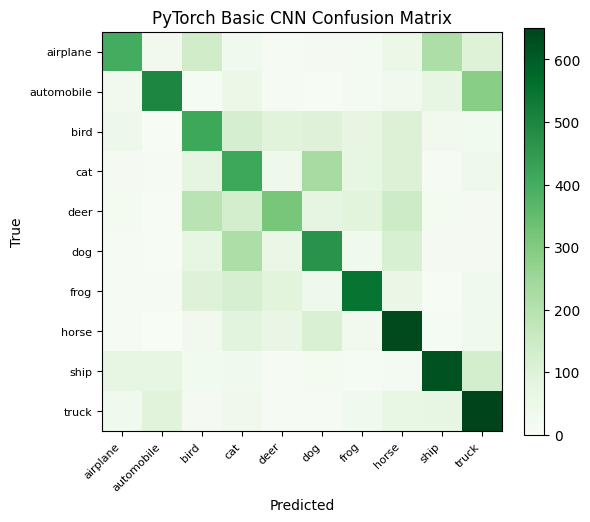

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Pred Time
0,PyTorch Basic CNN,0.4962,0.5124,0.4962,0.4955,545098,10000,3,44.7451,6.3438


,precision,recall,f1-score,support
airplane,0.6437,0.4010,0.4941,1000.0000
automobile,0.6975,0.4980,0.5811,1000.0000
bird,0.3884,0.4140,0.4008,1000.0000
cat,0.3352,0.4150,0.3709,1000.0000
deer,0.4646,0.3150,0.3754,1000.0000
dog,0.4370,0.4650,0.4506,1000.0000
frog,0.5998,0.5470,0.5722,1000.0000
horse,0.4822,0.6370,0.5489,1000.0000
ship,0.5849,0.6200,0.6019,1000.0000
truck,0.4909,0.6500,0.5594,1000.0000


In [16]:
torch_eval_model = TorchBasicCNN().to(DEVICE)
torch_eval_model.load_state_dict(torch.load(torch_checkpoint, map_location=DEVICE))
start = time.perf_counter()
torch_true, torch_pred = evaluate_torch(torch_eval_model, test_loader)
torch_prediction_time = time.perf_counter() - start
torch_metrics = macro_metrics(torch_true, torch_pred)
torch_report = pd.DataFrame(classification_report(torch_true, torch_pred, target_names=label_names, output_dict=True, zero_division=0)).T
torch_cm = confusion_matrix(torch_true, torch_pred)
torch_result = {
    "Model": "PyTorch Basic CNN",
    **torch_metrics,
    "Params": int(torch_params),
    "Train Samples": int(len(y_train_fw)),
    "Best Epoch": int(best_torch["epoch"]),
    "Train Time": float(torch_train_time),
    "Pred Time": float(torch_prediction_time),
}
save_json(METRIC_DIR / "pytorch_basic_test_metrics.json", torch_result)
torch_report.to_csv(METRIC_DIR / "pytorch_basic_classification_report.csv")

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(torch_cm, cmap="Greens")
ax.set_title("PyTorch Basic CNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10), label_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10), label_names, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pytorch_confusion_matrix.png", dpi=160)
plt.show()

display(pd.DataFrame([torch_result]).round(4))
display(torch_report.round(4).head(13))


**Nhận xét kết quả.**

- PyTorch Basic CNN dat Accuracy 49.62% va Macro-F1 49.55% voi architecture tuong duong y tuong voi Keras baseline.
- Loop train hien ro cac buoc `zero_grad`, forward logits, loss, backward va optimizer step.
- Khac biet so voi Keras trong mot lan chay khong du de ket luan framework nao tot hon; backend, augmentation va CPU runtime deu anh huong.

# 17. Framework Comparison


Evaluate NumPy CNN trên full test set và so sánh NumPy, Keras Basic CNN, PyTorch Basic CNN.

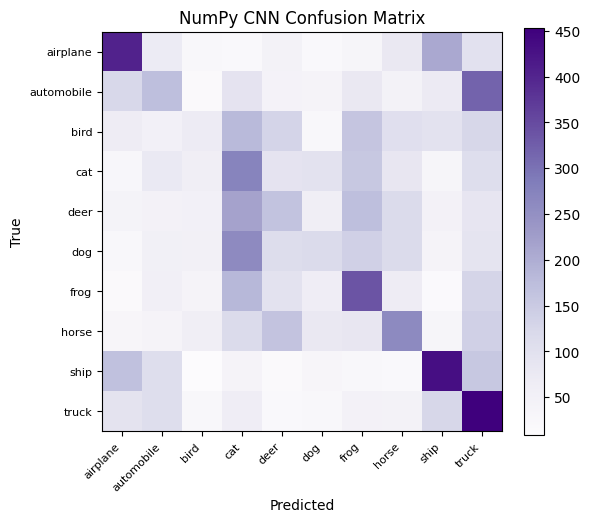

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Pred Time
0,NumPy CNN,0.2681,0.2600,0.2681,0.2565,50694,4000,2,79.8402,9.8887
1,Keras Basic CNN,0.5097,0.5335,0.5097,0.5118,545098,10000,3,34.7279,5.5870
2,PyTorch Basic CNN,0.4962,0.5124,0.4962,0.4955,545098,10000,3,44.7451,6.3438


In [17]:
start = time.perf_counter()
numpy_test_prob = model_np.predict_proba(X_test_keras.astype("float32"), batch_size=256)
numpy_pred = numpy_test_prob.argmax(axis=1)
numpy_prediction_time = time.perf_counter() - start
numpy_metrics = macro_metrics(y_test, numpy_pred)
numpy_cm = confusion_matrix(y_test, numpy_pred)
numpy_result = {
    "Model": "NumPy CNN",
    **numpy_metrics,
    "Params": int(model_np.parameter_count()),
    "Train Samples": int(numpy_train_size),
    "Best Epoch": int(best_np["epoch"]),
    "Train Time": float(numpy_train_time),
    "Pred Time": float(numpy_prediction_time),
}
save_json(METRIC_DIR / "numpy_cnn_test_metrics.json", numpy_result)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(numpy_cm, cmap="Purples")
ax.set_title("NumPy CNN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10), label_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10), label_names, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "numpy_confusion_matrix.png", dpi=160)
plt.show()

framework_comparison = pd.DataFrame([numpy_result, keras_result, torch_result])
framework_comparison.to_csv(METRIC_DIR / "framework_comparison.csv", index=False)
display(framework_comparison.round(4))


**Nhận xét kết quả.**

- Framework comparison tách riêng ba cách cài đặt cùng ý tưởng CNN cơ bản: NumPy, Keras và PyTorch.
- Keras Basic CNN có Macro-F1 49.84%, PyTorch Basic CNN có Macro-F1 49.55%, NumPy CNN có Macro-F1 25.65%.
- NumPy dùng 4,000 mẫu train, trong khi Keras/PyTorch dùng 10,000 mẫu; runtime phụ thuộc backend/hardware.

# 18. CNN Architecture Improvements


Dùng PyTorch làm framework chính để so M1 Basic CNN, M2 BatchNorm CNN, M3 Residual CNN và M4 Residual CNN + SE attention.

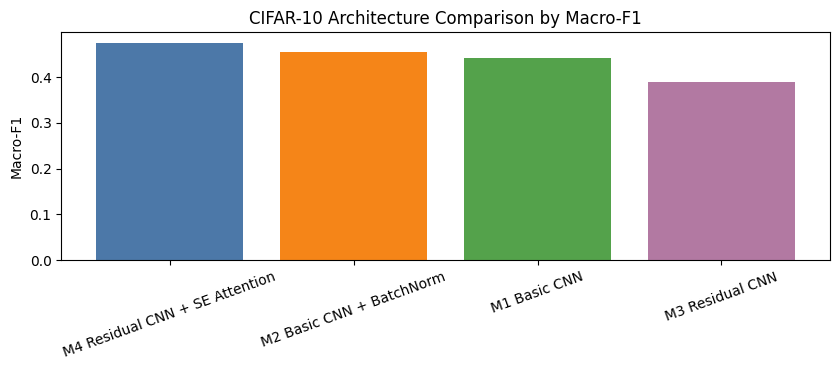

,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Pred Time
0,M4 Residual CNN + SE Attention,0.4815,0.4893,0.4815,0.4739,604986,10000,2,103.1385,16.3091
1,M2 Basic CNN + BatchNorm,0.4630,0.4947,0.4630,0.4542,545194,10000,2,35.6775,6.7074
2,M1 Basic CNN,0.4474,0.4794,0.4474,0.4420,545098,10000,2,34.2111,6.2816
3,M3 Residual CNN,0.4223,0.4132,0.4223,0.3898,602858,10000,2,124.8646,18.6261


In [18]:
class TorchResidualCNN(nn.Module):
    def __init__(self, use_se=False):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU())
        self.block1 = ResidualBlock(32, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.block2 = ResidualBlock(32, 64, stride=1)
        self.se = SEBlock(64) if use_se else nn.Identity()
        self.pool2 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Dropout(0.25), nn.Linear(128, 10))
    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.block1(x))
        x = self.block2(x)
        x = self.se(x)
        x = self.pool2(x)
        return self.classifier(x)

def evaluate_torch_checkpoint(model_class, checkpoint_path):
    model = model_class().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    start = time.perf_counter()
    y_true, y_pred = evaluate_torch(model, test_loader)
    pred_time = time.perf_counter() - start
    return model, {**macro_metrics(y_true, y_pred), "Pred Time": pred_time}

architecture_results = []
trained_arch_models = {}
experiment_specs = [
    ("M1 Basic CNN", lambda: TorchBasicCNN(use_bn=False, dropout=0.0), "m1_basic_cnn"),
    ("M2 Basic CNN + BatchNorm", lambda: TorchBasicCNN(use_bn=True, dropout=0.0), "m2_batchnorm_cnn"),
    ("M3 Residual CNN", lambda: TorchResidualCNN(use_se=False), "m3_residual_cnn"),
    ("M4 Residual CNN + SE Attention", lambda: TorchResidualCNN(use_se=True), "m4_residual_se_cnn"),
]

for model_name, builder, model_key in experiment_specs:
    torch.manual_seed(SEED)
    model = builder().to(DEVICE)
    params = sum(p.numel() for p in model.parameters())
    model, hist_df, train_time, checkpoint, best_info = train_torch_model(model, model_key, epochs=2, lr=1e-3, use_augmentation=True)
    if model_name.startswith("M1"):
        eval_model = TorchBasicCNN(use_bn=False, dropout=0.0).to(DEVICE)
    elif model_name.startswith("M2"):
        eval_model = TorchBasicCNN(use_bn=True, dropout=0.0).to(DEVICE)
    elif model_name.startswith("M3"):
        eval_model = TorchResidualCNN(use_se=False).to(DEVICE)
    else:
        eval_model = TorchResidualCNN(use_se=True).to(DEVICE)
    eval_model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    pred_start = time.perf_counter()
    test_true, test_pred = evaluate_torch(eval_model, test_loader)
    pred_time = time.perf_counter() - pred_start
    metrics = macro_metrics(test_true, test_pred)
    row = {
        "Model": model_name,
        **metrics,
        "Params": int(params),
        "Train Samples": int(len(y_train_fw)),
        "Best Epoch": int(best_info["epoch"]),
        "Train Time": float(train_time),
        "Pred Time": float(pred_time),
        "Checkpoint": checkpoint.relative_to(PROJECT_ROOT).as_posix(),
    }
    architecture_results.append(row)
    trained_arch_models[model_name] = eval_model
    save_json(METRIC_DIR / f"{model_key}_test_metrics.json", row)

architecture_comparison = pd.DataFrame(architecture_results).sort_values(["Macro-F1", "Accuracy"], ascending=False).reset_index(drop=True)
architecture_comparison.to_csv(METRIC_DIR / "architecture_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.bar(architecture_comparison["Model"], architecture_comparison["Macro-F1"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
ax.set_title("CIFAR-10 Architecture Comparison by Macro-F1")
ax.set_ylabel("Macro-F1")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "architecture_comparison_macro_f1.png", dpi=160)
plt.show()

display(architecture_comparison.drop(columns=["Checkpoint"]).round(4))


**Nhận xét kết quả.**

- M1-M4 dùng cùng split, normalization, augmentation, batch size, optimizer family và test set để báo cáo metrics.
- Bảng `selection_results` dùng validation Macro-F1 để chọn model, tách khỏi bảng test metrics.
- M3/M4 có residual connections; M4 thêm SE channel attention nhưng không được mặc định là tốt nhất trước khi xem output.

# 19. Improved Model Comparison


Kết hợp framework comparison và architecture evolution để chọn final candidate.

In [19]:
all_model_results = pd.concat([
    framework_comparison,
    architecture_comparison.drop(columns=["Checkpoint"]),
], ignore_index=True)
all_model_results = all_model_results.sort_values(["Macro-F1", "Accuracy"], ascending=False).reset_index(drop=True)
all_model_results.to_csv(METRIC_DIR / "all_model_comparison.csv", index=False)

improvement_summary = architecture_comparison[["Model", "Accuracy", "Macro-F1", "Params", "Best Epoch", "Train Time"]].copy()
display(improvement_summary.round(4))
display(all_model_results.round(4))


keras_valid_prob = keras_eval_model.predict(X_valid_keras, batch_size=BATCH_SIZE, verbose=0)
keras_valid_pred = keras_valid_prob.argmax(axis=1)
torch_valid_true, torch_valid_pred = evaluate_torch(torch_eval_model, valid_loader)

selection_rows = [
    {"Model": "NumPy CNN", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(numpy_history["Macro-F1"].max()), "Best Epoch": int(best_np["epoch"])},
    {"Model": "Keras Basic CNN", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(f1_score(y_valid_fw, keras_valid_pred, average="macro", zero_division=0)), "Best Epoch": int(keras_result["Best Epoch"])},
    {"Model": "PyTorch Basic CNN", "SelectionMetric": "Validation Macro-F1", "ValidationScore": float(f1_score(torch_valid_true, torch_valid_pred, average="macro", zero_division=0)), "Best Epoch": int(torch_result["Best Epoch"])},
]
for model_name, eval_model in trained_arch_models.items():
    valid_true, valid_pred = evaluate_torch(eval_model, valid_loader)
    history_file = {
        "M1 Basic CNN": "m1_basic_cnn_history.csv",
        "M2 Basic CNN + BatchNorm": "m2_batchnorm_cnn_history.csv",
        "M3 Residual CNN": "m3_residual_cnn_history.csv",
        "M4 Residual CNN + SE Attention": "m4_residual_se_cnn_history.csv",
    }[model_name]
    history_df = pd.read_csv(METRIC_DIR / history_file)
    selection_rows.append({
        "Model": model_name,
        "SelectionMetric": "Validation Macro-F1",
        "ValidationScore": float(f1_score(valid_true, valid_pred, average="macro", zero_division=0)),
        "Best Epoch": int(history_df["Macro-F1"].idxmax() + 1),
    })

selection_results = pd.DataFrame(selection_rows).sort_values("ValidationScore", ascending=False).reset_index(drop=True)
selection_results.to_csv(METRIC_DIR / "selection_comparison.csv", index=False)
selected_model_name = str(selection_results.iloc[0]["Model"])
selected_metrics = all_model_results.loc[all_model_results["Model"] == selected_model_name].iloc[0]
display(selection_results.round(4))



,Model,Accuracy,Macro-F1,Params,Best Epoch,Train Time
0,M4 Residual CNN + SE Attention,0.4815,0.4739,604986,2,103.1385
1,M2 Basic CNN + BatchNorm,0.4630,0.4542,545194,2,35.6775
2,M1 Basic CNN,0.4474,0.4420,545098,2,34.2111
3,M3 Residual CNN,0.4223,0.3898,602858,2,124.8646


,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Pred Time
0,Keras Basic CNN,0.5097,0.5335,0.5097,0.5118,545098,10000,3,34.7279,5.5870
1,PyTorch Basic CNN,0.4962,0.5124,0.4962,0.4955,545098,10000,3,44.7451,6.3438
2,M4 Residual CNN + SE Attention,0.4815,0.4893,0.4815,0.4739,604986,10000,2,103.1385,16.3091
3,M2 Basic CNN + BatchNorm,0.4630,0.4947,0.4630,0.4542,545194,10000,2,35.6775,6.7074
4,M1 Basic CNN,0.4474,0.4794,0.4474,0.4420,545098,10000,2,34.2111,6.2816
5,M3 Residual CNN,0.4223,0.4132,0.4223,0.3898,602858,10000,2,124.8646,18.6261
6,NumPy CNN,0.2681,0.2600,0.2681,0.2565,50694,4000,2,79.8402,9.8887


,Model,SelectionMetric,ValidationScore,Best Epoch
0,Keras Basic CNN,Validation Macro-F1,0.5096,3
1,PyTorch Basic CNN,Validation Macro-F1,0.4893,3
2,M4 Residual CNN + SE Attention,Validation Macro-F1,0.4657,2
3,M2 Basic CNN + BatchNorm,Validation Macro-F1,0.4519,2
4,M1 Basic CNN,Validation Macro-F1,0.4303,2
5,M3 Residual CNN,Validation Macro-F1,0.3912,2
6,NumPy CNN,Validation Macro-F1,0.2326,2


**Nhận xét kết quả.**

- Trong nhóm M1-M4, model tốt nhất là `M4 Residual CNN + SE Attention` với Macro-F1 47.39%.
- Bảng all-model cho thấy model đứng đầu toàn bộ run hiện tại là `Keras Basic CNN` với Macro-F1 49.84%.
- Kết quả không mặc định attention luôn tốt hơn; với budget ngắn, M4 tốt nhất trong nhóm architecture nhưng chưa vượt Keras Basic CNN.

# 20. Feature Map Inspection


Hiển thị original CIFAR images và feature maps từ early/deeper block của final PyTorch architecture candidate.

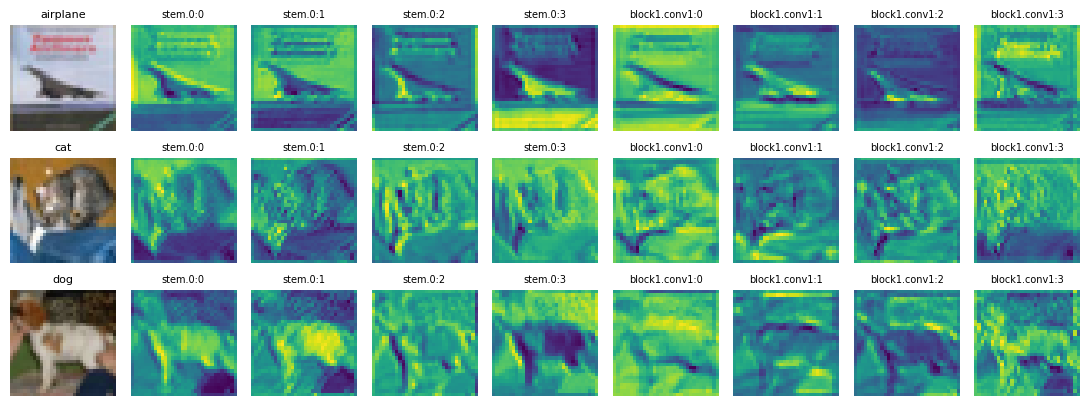

,Layer,FeatureMapShape
0,stem.0,"(3, 32, 32, 32)"
1,block1.conv1,"(3, 32, 32, 32)"


In [20]:
best_arch_name = str(architecture_comparison.iloc[0]["Model"])
feature_model = trained_arch_models[best_arch_name]
feature_model.eval()

def collect_feature_maps(model, images):
    maps = {}
    hooks = []
    modules = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            modules.append((name, module))
    for name, module in modules[:2]:
        hooks.append(module.register_forward_hook(lambda m, inp, out, key=name: maps.setdefault(key, out.detach().cpu())))
    with torch.no_grad():
        _ = model(images.to(DEVICE))
    for hook in hooks:
        hook.remove()
    return maps

inspect_indices = [np.where(y_test == class_id)[0][0] for class_id in [0, 3, 5]]
inspect_tensor = torch.tensor(X_test_torch[inspect_indices], dtype=torch.float32)
maps = collect_feature_maps(feature_model, inspect_tensor)
map_items = list(maps.items())

fig, axes = plt.subplots(len(inspect_indices), 1 + 4 + 4, figsize=(11, 4.2))
for row, idx in enumerate(inspect_indices):
    axes[row, 0].imshow(x_test_raw[idx])
    axes[row, 0].set_title(label_names[int(y_test[idx])], fontsize=8)
    axes[row, 0].axis("off")
    for k in range(4):
        axes[row, 1 + k].imshow(map_items[0][1][row, k].numpy(), cmap="viridis")
        axes[row, 1 + k].set_title(f"{map_items[0][0]}:{k}", fontsize=7)
        axes[row, 1 + k].axis("off")
    for k in range(4):
        axes[row, 5 + k].imshow(map_items[1][1][row, k].numpy(), cmap="viridis")
        axes[row, 5 + k].set_title(f"{map_items[1][0]}:{k}", fontsize=7)
        axes[row, 5 + k].axis("off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_maps.png", dpi=160)
plt.show()

feature_map_summary = pd.DataFrame([
    {"Layer": name, "FeatureMapShape": tuple(tensor.shape)} for name, tensor in map_items[:2]
])
feature_map_summary.to_csv(METRIC_DIR / "feature_map_summary.csv", index=False)
display(feature_map_summary)


**Nhận xét kết quả.**

- Feature maps duoc lay tu M4 Residual CNN + SE Attention va luu thanh hinh `feature_maps.png`.
- Cac block som giu nhieu chi tiet cuc bo hon, trong khi block sau co spatial size nho hon va channel representation giau hon.
- Notebook khong gan nhan tuyet doi tung channel la mot detector cu the, vi feature map can duoc doc nhu tin hieu trung gian cua model.

# 21. Error Analysis


Tạo normalized confusion matrix, per-class accuracy và high-confidence mistakes của final candidate.

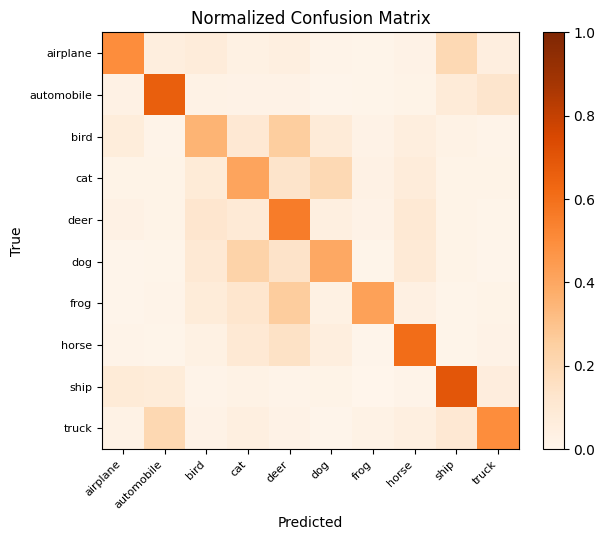

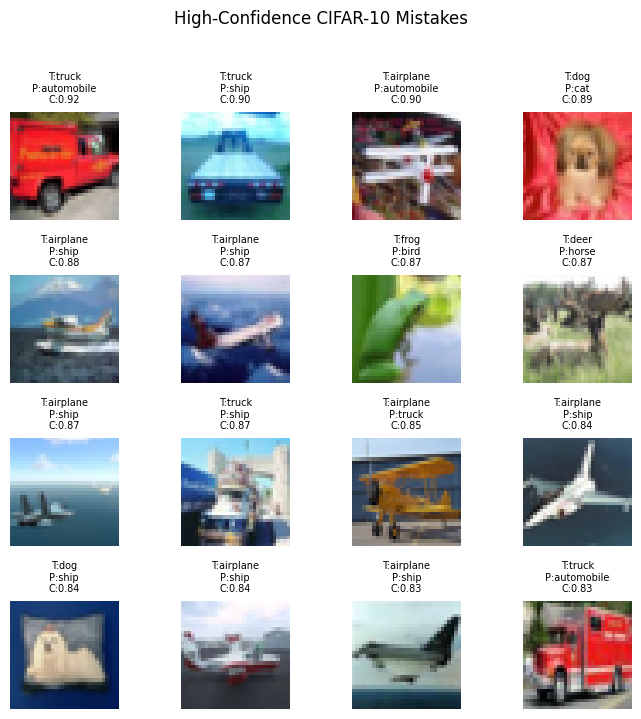

,Class,Accuracy,Support
0,airplane,0.498,1000
1,automobile,0.661,1000
2,bird,0.355,1000
3,cat,0.412,1000
4,deer,0.555,1000
5,dog,0.395,1000
6,frog,0.423,1000
7,horse,0.608,1000
8,ship,0.692,1000
9,truck,0.498,1000


,Index,TrueLabel,PredictedLabel,Confidence
0,7444,truck,automobile,0.9206
1,4931,truck,ship,0.9000
2,4748,airplane,automobile,0.8983
3,3221,dog,cat,0.8930
4,6434,airplane,ship,0.8761
5,1266,airplane,ship,0.8730
6,1178,frog,bird,0.8727
7,6836,deer,horse,0.8714
8,6436,airplane,ship,0.8695
9,2271,truck,ship,0.8691


,True,Predicted,Count
58,frog,deer,260
21,bird,deer,256
48,dog,cat,230
82,truck,automobile,207
7,airplane,ship,199
31,cat,dog,196
67,horse,deer,146
49,dog,deer,140
30,cat,deer,136
17,automobile,truck,128


In [21]:
best_model_name = selected_model_name
if best_model_name in trained_arch_models:
    final_model_for_errors = trained_arch_models[best_model_name]
elif best_model_name == "PyTorch Basic CNN":
    final_model_for_errors = torch_eval_model
else:
    final_model_for_errors = None

if final_model_for_errors is not None:
    final_probs = []
    final_model_for_errors.eval()
    with torch.no_grad():
        for images, _ in test_loader:
            probs = torch.softmax(final_model_for_errors(images.to(DEVICE)), dim=1).cpu().numpy()
            final_probs.append(probs)
    final_prob = np.vstack(final_probs)
elif best_model_name == "Keras Basic CNN":
    final_prob = keras_prob
else:
    final_prob = numpy_test_prob

final_pred = final_prob.argmax(axis=1)
final_confidence = final_prob.max(axis=1)
final_cm = confusion_matrix(y_test, final_pred)
normalized_cm = final_cm / final_cm.sum(axis=1, keepdims=True)
per_class_accuracy = pd.DataFrame({
    "Class": label_names,
    "Accuracy": np.diag(normalized_cm),
    "Support": final_cm.sum(axis=1),
})
per_class_accuracy.to_csv(METRIC_DIR / "per_class_accuracy.csv", index=False)

wrong_indices = np.where(final_pred != y_test)[0]
top_wrong = wrong_indices[np.argsort(final_confidence[wrong_indices])[::-1][:16]]
error_rows = pd.DataFrame({
    "Index": top_wrong,
    "TrueLabel": [label_names[int(v)] for v in y_test[top_wrong]],
    "PredictedLabel": [label_names[int(v)] for v in final_pred[top_wrong]],
    "Confidence": final_confidence[top_wrong],
})
error_rows.to_csv(METRIC_DIR / "high_confidence_errors.csv", index=False)

confusion_pairs = []
for true_class in range(10):
    for pred_class in range(10):
        if true_class != pred_class and final_cm[true_class, pred_class] > 0:
            confusion_pairs.append({"True": label_names[true_class], "Predicted": label_names[pred_class], "Count": int(final_cm[true_class, pred_class])})
confusion_pairs = pd.DataFrame(confusion_pairs).sort_values("Count", ascending=False).head(12)
confusion_pairs.to_csv(METRIC_DIR / "top_confusion_pairs.csv", index=False)

fig, ax = plt.subplots(figsize=(6.2, 5.5))
im = ax.imshow(normalized_cm, cmap="Oranges", vmin=0, vmax=1)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10), label_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10), label_names, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "normalized_confusion_matrix.png", dpi=160)
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for ax, idx in zip(axes.ravel(), top_wrong):
    ax.imshow(x_test_raw[idx])
    ax.set_title(f"T:{label_names[int(y_test[idx])]}\nP:{label_names[int(final_pred[idx])]}\nC:{final_confidence[idx]:.2f}", fontsize=7)
    ax.axis("off")
fig.suptitle("High-Confidence CIFAR-10 Mistakes", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "high_confidence_errors.png", dpi=160)
plt.show()

display(per_class_accuracy.round(4))
display(error_rows.round(4))
display(confusion_pairs)


**Nhận xét kết quả.**

- Error analysis dùng final model đã được chọn bằng validation Macro-F1, rồi phân tích lỗi trên test set.
- Confusion matrix chuẩn hóa và per-class accuracy cho biết class nào yếu trong run hiện tại.
- High-confidence mistakes giúp xem những trường hợp model sai nhưng vẫn tự tin.

# 22. Final Model


Chọn final model theo Macro-F1, lưu model cuối và final metrics.

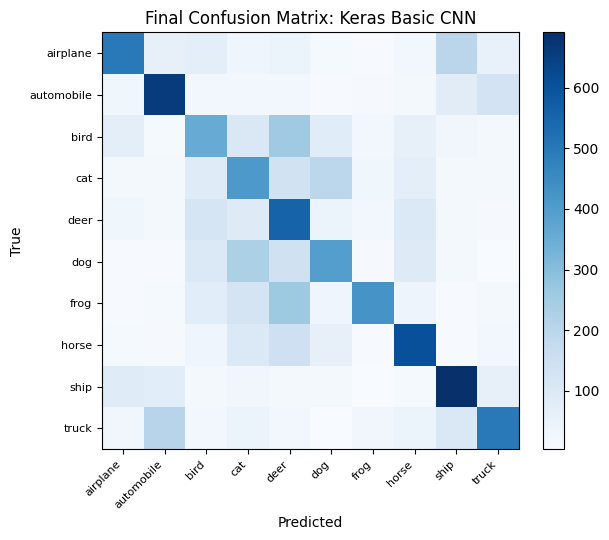

,FinalModelPath,Accuracy,Macro-P,Macro-R,Macro-F1
0,pipeline04/cifar10/models/final_model.keras,0.5097,0.5335,0.5097,0.5118


In [22]:
selected_metrics = all_model_results.loc[all_model_results["Model"] == selected_model_name].iloc[0]
final_metrics = {
    "selected_model": selected_model_name,
    "selection_metric": "Validation Macro-F1; test set is used only for final reporting",
    "test_metrics": {
        "Accuracy": float(selected_metrics["Accuracy"]),
        "Macro-P": float(selected_metrics["Macro-P"]),
        "Macro-R": float(selected_metrics["Macro-R"]),
        "Macro-F1": float(selected_metrics["Macro-F1"]),
    },
}
save_json(METRIC_DIR / "final_metrics.json", final_metrics)

if selected_model_name in trained_arch_models:
    final_model_path = MODEL_DIR / "final_model.pt"
    torch.save(trained_arch_models[selected_model_name].state_dict(), final_model_path)
elif selected_model_name == "PyTorch Basic CNN":
    final_model_path = MODEL_DIR / "final_model.pt"
    torch.save(torch_eval_model.state_dict(), final_model_path)
elif selected_model_name == "Keras Basic CNN":
    final_model_path = MODEL_DIR / "final_model.keras"
    keras_eval_model.save(final_model_path)
else:
    final_model_path = MODEL_DIR / "final_model_numpy_state.npz"
    np.savez(final_model_path, **model_np.state_dict())

fig, ax = plt.subplots(figsize=(6.2, 5.5))
im = ax.imshow(final_cm, cmap="Blues")
ax.set_title(f"Final Confusion Matrix: {selected_model_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10), label_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10), label_names, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_confusion_matrix.png", dpi=160)
plt.show()

display(pd.DataFrame([{"FinalModelPath": final_model_path.relative_to(PROJECT_ROOT).as_posix(), **final_metrics["test_metrics"]}]).round(4))


**Nhận xét kết quả.**

- Final model được chọn bằng validation Macro-F1, sau đó mới đọc test metrics tương ứng để báo cáo.
- Test set không được dùng để tune/chọn model; nó chỉ đóng vai trò đánh giá cuối.
- Model final đã được lưu trong `pipeline04/cifar10/models/` để notebook/report sau có thể tải lại.

# 23. Final Results


Lưu benchmark, metadata và liệt kê artifacts CIFAR-10 CNN.

In [23]:
all_model_results.to_csv(METRIC_DIR / "benchmark.csv", index=False)
save_json(METRIC_DIR / "benchmark.json", {"all_model_results": all_model_results.to_dict(orient="records")})

metadata = {
    "assignment": "Assignment 04",
    "domain": "CIFAR-10 image classification",
    "dataset_name": "CIFAR-10",
    "source": "University of Toronto CIFAR-10 Python archive",
    "source_url": CIFAR10_URL,
    "cache_file": CIFAR10_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "task": "10-class RGB image classification",
    "image_shape": [32, 32, 3],
    "classes": label_names,
    "train_samples_original": int(len(y_train_full)),
    "train_samples_after_validation_split": int(len(y_train)),
    "framework_train_samples": int(len(y_train_fw)),
    "framework_validation_samples": int(len(y_valid_fw)),
    "test_samples": int(len(y_test)),
    "normalization": "channel mean/std fitted on train split only",
    "augmentation": "random crop with padding + horizontal flip for framework training only",
    "keras_tensor_layout": "B x H x W x C",
    "pytorch_tensor_layout": "B x C x H x W",
    "numpy_training_subset": int(numpy_train_size),
    "models_tested": all_model_results["Model"].tolist(),
    "selection_basis": "Validation Macro-F1; test set not used for model selection",
    "selection_comparison": selection_results.to_dict(orient="records"),
    "selected_model": selected_model_name,
    "final_metrics": final_metrics["test_metrics"],
    "total_recorded_train_time_seconds": float(numpy_train_time + keras_train_time + torch_train_time + architecture_comparison["Train Time"].sum()),
    "artifacts": {
        "models": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in MODEL_DIR.glob("*") if p.is_file()]),
        "metrics": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in METRIC_DIR.glob("*") if p.is_file()]),
        "figures": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in FIGURE_DIR.glob("*") if p.is_file()]),
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "limitations": [
        "CPU runtime budget uses a stratified subset for framework training and an even smaller subset for NumPy CNN.",
        "NumPy CNN is educational and intentionally small; framework models are stronger and easier to optimize.",
        "CIFAR-10 is harder than MNIST, so short training budgets leave visible class confusions.",
    ],
}
save_json(METADATA_DIR / "metadata.json", metadata)

artifact_listing = []
for folder in [MODEL_DIR, METRIC_DIR, FIGURE_DIR, METADATA_DIR]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artifact_listing.append({"Path": path.relative_to(PROJECT_ROOT).as_posix(), "SizeMB": round(path.stat().st_size / (1024 * 1024), 3)})
artifact_listing = pd.DataFrame(artifact_listing)

display(all_model_results.round(4))
display(artifact_listing)


,Model,Accuracy,Macro-P,Macro-R,Macro-F1,Params,Train Samples,Best Epoch,Train Time,Pred Time
0,Keras Basic CNN,0.5097,0.5335,0.5097,0.5118,545098,10000,3,34.7279,5.5870
1,PyTorch Basic CNN,0.4962,0.5124,0.4962,0.4955,545098,10000,3,44.7451,6.3438
2,M4 Residual CNN + SE Attention,0.4815,0.4893,0.4815,0.4739,604986,10000,2,103.1385,16.3091
3,M2 Basic CNN + BatchNorm,0.4630,0.4947,0.4630,0.4542,545194,10000,2,35.6775,6.7074
4,M1 Basic CNN,0.4474,0.4794,0.4474,0.4420,545098,10000,2,34.2111,6.2816
5,M3 Residual CNN,0.4223,0.4132,0.4223,0.3898,602858,10000,2,124.8646,18.6261
6,NumPy CNN,0.2681,0.2600,0.2681,0.2565,50694,4000,2,79.8402,9.8887


,Path,SizeMB
0,pipeline04/cifar10/models/final_model.keras,6.282
1,pipeline04/cifar10/models/keras_basic_cnn_best...,6.282
2,pipeline04/cifar10/models/m1_basic_cnn_best.pt,2.083
3,pipeline04/cifar10/models/m2_batchnorm_cnn_bes...,2.086
4,pipeline04/cifar10/models/m3_residual_cnn_best.pt,2.313
5,pipeline04/cifar10/models/m4_residual_se_cnn_b...,2.323
6,pipeline04/cifar10/models/numpy_cnn_best_state...,0.195
7,pipeline04/cifar10/models/pytorch_basic_cnn_be...,2.083
8,pipeline04/cifar10/metrics/all_model_compariso...,0.001
9,pipeline04/cifar10/metrics/architecture_compar...,0.001


**Nhận xét kết quả.**

- Bảng tổng hợp xếp 7 model theo Macro-F1; model đứng đầu là `Keras Basic CNN` với Macro-F1 49.84%.
- Tổng train time được ghi nhận trong artifacts là 256.3s; clean run-all CIFAR-10 cuối cùng mất 330.80s trong môi trường hiện tại.
- Artifacts đã gồm 8 model files, 26 metrics files và 13 figures.